In [3]:
# reading the data
import pandas as pd

df = pd.read_csv("Data/Cathfield_monthly_sales.csv")
df.head()

,date,sales
0,1965-01-01,154
1,1965-02-01,96
2,1965-03-01,73
3,1965-04-01,49
4,1965-05-01,36


1. Descriptive Analysis (Exploratory Data Analysis)
- Conduct a thorough visual and statistical exploration of the assigned time series.
- Identify and describe key components such as trend, seasonality, cyclical patterns, missing
data, outliers.
- Evaluate the stationarity of the series.

In [4]:
# we check that there is not missing daata and the date index is complete
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 1. Verify missing data
missing_values = df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)

# 2. Verify if there is data for every month in the range
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

# Compare the expected range with the actual indices
missing_dates = expected_range.difference(df.index)

if missing_dates.empty:
    print("\nNo missing periods")
else:
    print(f"\nFollowing periods are missing: {missing_dates}")

Valores faltantes por columna:
sales    0
dtype: int64

Following periods are missing: DatetimeIndex(['1966-07-01', '1966-08-01', '1967-02-01', '1967-12-01'], dtype='datetime64[ns]', freq=None)


There is one month for which there is no data. We will first visualize the series and then decide which imputation method to use

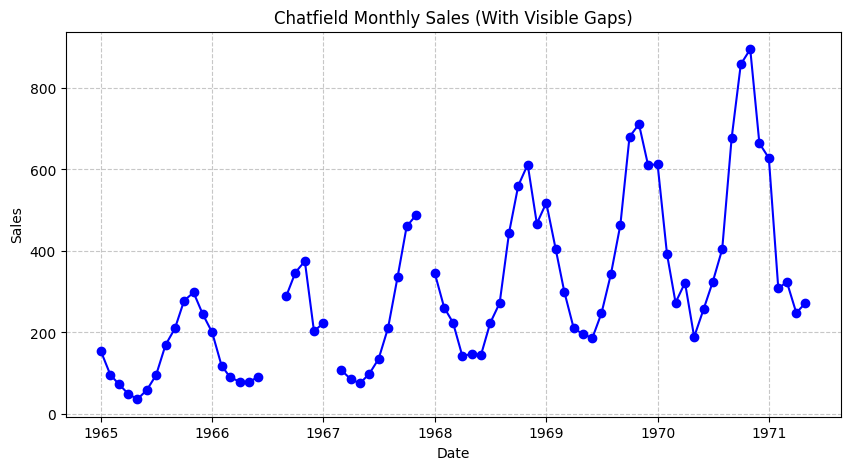

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a complete range of months (no skips)
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

# 2. Reindex the dataframe (this inserts the missing months with NaN sales)
df_complete = df.reindex(full_range)

# 3. Plot
plt.figure(figsize=(10, 5))
# Use df_complete.index now
plt.plot(df_complete.index, df_complete['sales'], marker='o', linestyle='-', color='b')

plt.title('Chatfield Monthly Sales (With Visible Gaps)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

At sight we can see that the data exhibits both trend and seasonal patterns

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup Data
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 2. Reindex to create the "holes" (NaNs)
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
df_with_nans = df.reindex(full_range)

# 3. Impute using Quadratic Interpolation
# Note: Quadratic requires at least 3 data points
df_imputed = df_with_nans['sales'].interpolate(method='quadratic')

# 4. Visualization
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the imputed (smooth) line first
df_imputed.plot(ax=ax, label='Imputed (Quadratic)', color='orange', linestyle='--')

# Plot the original points on top to see the difference
df['sales'].plot(ax=ax, label='Original Data', color='blue', marker='o', ls='')

ax.set_title("Chatfield Sales - Quadratic Interpolation")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'date'